### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from collections import Counter
import re

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from collections import Counter
import re

### Load Data

In [6]:
DATA_PATH = "../data/IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (40000, 2)


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


### Basic Info

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     40000 non-null  str  
 1   sentiment  40000 non-null  str  
dtypes: str(2)
memory usage: 50.9 MB


In [8]:
df.describe(include='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7924\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,review,sentiment
count,40000,40000
unique,39731,2
top,"Hilarious, clean, light-hearted, and quote-wor...",positive
freq,4,20004


### Check Missing Values

In [9]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

### Class Distribution

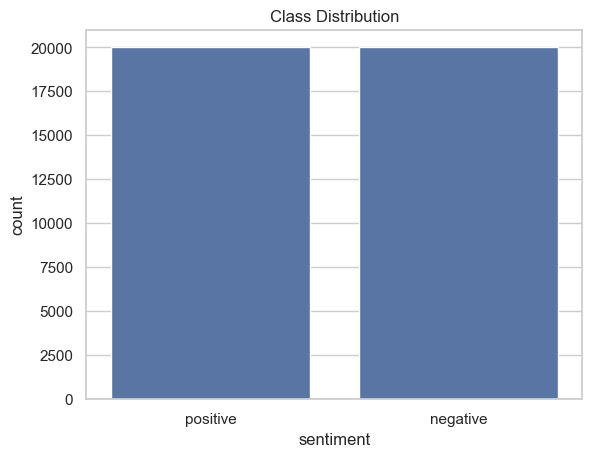

In [10]:
sns.countplot(x='sentiment', data=df)
plt.title("Class Distribution")
plt.show()

In [11]:
df['sentiment'].value_counts(normalize=True)

sentiment
positive    0.5001
negative    0.4999
Name: proportion, dtype: float64

### Sample Reviews

In [12]:
print("Positive Review Example:\n")
print(df[df['sentiment'] == 'positive']['review'].iloc[0])

print("\n\nNegative Review Example:\n")
print(df[df['sentiment'] == 'negative']['review'].iloc[0])

Positive Review Example:

I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers,

### Review Length Analysis

In [13]:
def word_count(text):
    return len(str(text).split())

df['word_count'] = df['review'].apply(word_count)

#### Summary statistics

In [14]:
print("Average length:", df['word_count'].mean())
print("Median length:", df['word_count'].median())
print("90th percentile:", df['word_count'].quantile(0.9))
print("Max length:", df['word_count'].max())
print("Min length:", df['word_count'].min())

Average length: 231.449875
Median length: 174.0
90th percentile: 451.0
Max length: 2470
Min length: 6


### Distribution Plot

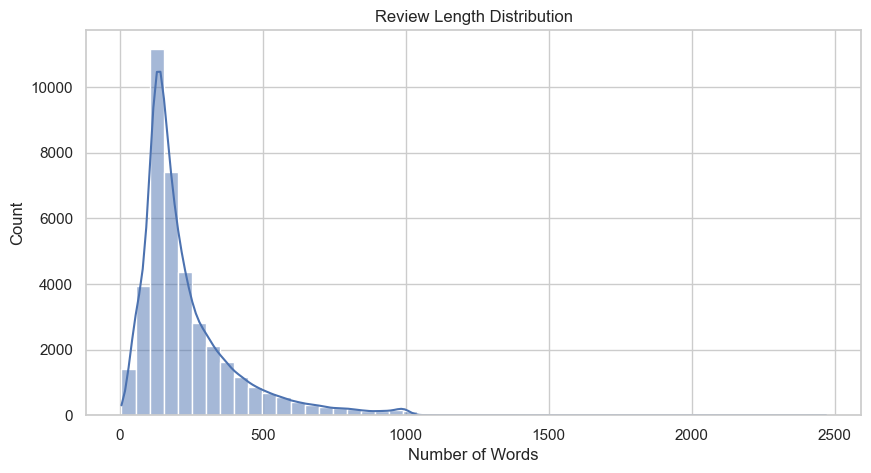

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.show()

### Positive vs Negative Length

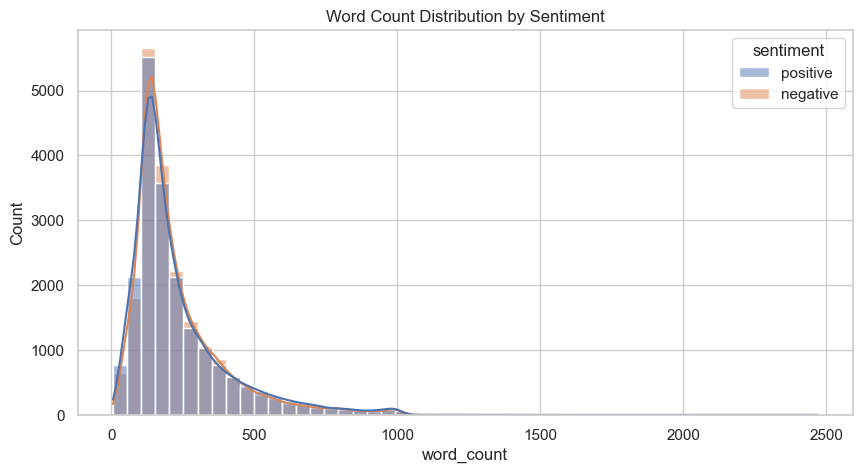

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True)
plt.title("Word Count Distribution by Sentiment")
plt.show()

### Boxplot (Outliers)

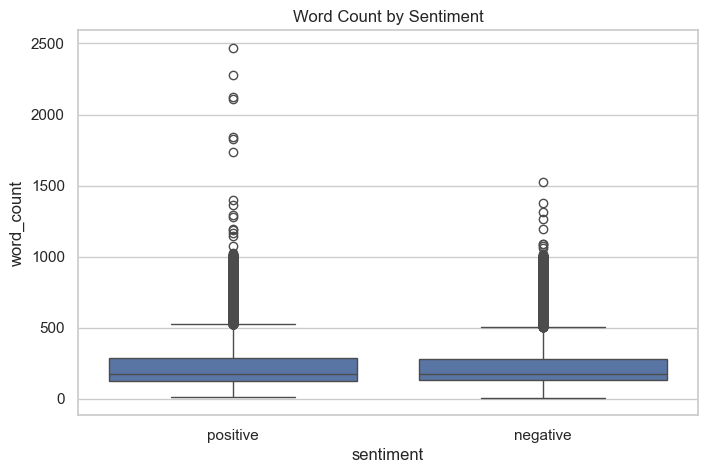

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Word Count by Sentiment")
plt.show()

### Text Cleaning Demo

In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

sample = df['review'].iloc[0]

print("Original:\n", sample[:300])
print("\nCleaned:\n", clean_text(sample)[:300])

Original:
 I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 

Cleaned:
 i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslam s ever if the wwf didn t have lex luger in the main event against yokozuna now for it s time it was ok to h


### Most Common Words

In [19]:
def get_words(text):
    return clean_text(text).split()

all_words = []

for review in df['review'].sample(10000, random_state=42):  # sample for speed
    all_words.extend(get_words(review))

word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

common_words

[('the', 134269),
 ('and', 65181),
 ('a', 64578),
 ('of', 57421),
 ('to', 53513),
 ('is', 42336),
 ('it', 38511),
 ('in', 37533),
 ('i', 35069),
 ('this', 30003),
 ('that', 28726),
 ('s', 25701),
 ('was', 19195),
 ('as', 18237),
 ('movie', 17590),
 ('for', 17536),
 ('with', 17311),
 ('but', 16647),
 ('film', 16129),
 ('you', 13859)]

### Plot Common Words

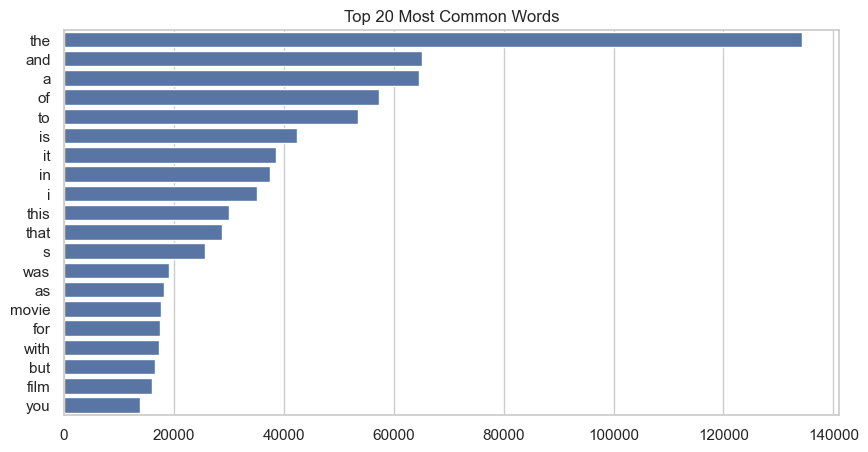

In [20]:
words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Common Words")
plt.show()

Key Observations
- The dataset is balanced between positive and negative reviews.
- Reviews vary significantly in length, with some exceeding 1000+ words.
- The distribution is right-skewed, indicating presence of long outliers.
- Positive and negative reviews have similar length distributions.
- Raw text contains HTML tags, punctuation, and noisy tokens.
- Common words include many stopwords, motivating preprocessing.